# ❤️ Heart Disease Prediction — Machine Learning Classification

### Contents
1. [Load, Explore & Preprocess](#step-1)
2. [Feature Engineering](#step-2)
3. [Train Models](#step-3)
4. [Evaluate & Compare](#step-4)
5. [Best Model Analysis & Conclusion](#step-5)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_val_score, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve)

DATA_PATH = "data/heart.csv"
IMG_DIR, MODEL_DIR = "images", "models"
os.makedirs(IMG_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)

<a id="step-1"></a>
---
## Step 1 — Load, Explore & Preprocess

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 1,025 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Data dictionary
| Column | Meaning | Type |
|---|---|---|
| `age` | Age in years | numeric |
| `sex` | 1 = male, 0 = female | binary |
| `cp` | Chest-pain type (0–3) | categorical (nominal) |
| `trestbps` | Resting blood pressure (mm Hg) | numeric |
| `chol` | Serum cholesterol (mg/dl) | numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = yes) | binary |
| `restecg` | Resting ECG result (0–2) | categorical (nominal) |
| `thalach` | Maximum heart rate achieved | numeric |
| `exang` | Exercise-induced angina (1 = yes) | binary |
| `oldpeak` | ST depression induced by exercise | numeric |
| `slope` | Slope of the peak-exercise ST segment (0–2) | categorical |
| `ca` | Number of major vessels coloured by fluoroscopy (0–4) | numeric count |
| `thal` | Thalassemia test result (0–3) | categorical (nominal) |
| **`target`** | **Heart-disease label (the value to predict)** | binary |

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
print("Missing values per column:")
print(df_raw.isna().sum().to_string())
print("\nTotal missing values:", int(df_raw.isna().sum().sum()))
df_raw.describe().T.round(2)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0

Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.43,9.07,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.70,0.46,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.94,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.61,17.52,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.00,51.59,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.11,23.01,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.07,1.18,0.0,0.0,0.8,1.8,6.2


### 1.1 Duplicates — the most important data-quality check

In [6]:
n_dup = int(df_raw.duplicated().sum())
print(f"Duplicate rows: {n_dup} of {len(df_raw)} ({n_dup / len(df_raw):.1%})")
print(f"Unique patients/records: {len(df_raw) - n_dup}")

Duplicate rows: 723 of 1025 (70.5%)
Unique patients/records: 302


Only **302 unique records** exist; the other 723 rows are exact copies. If copies land on both sides of a train/test split, the model is tested on rows it has already memorised (**data leakage**). The next cell proves the effect using the same model and split, on raw vs de-duplicated data.

In [7]:
def quick_rf_accuracy(data):
    X_, y_ = data.drop(columns="target"), data["target"]
    Xtr_, Xte_, ytr_, yte_ = train_test_split(X_, y_, test_size=0.2, stratify=y_, random_state=42)
    rf = RandomForestClassifier(random_state=42).fit(Xtr_, ytr_)
    return accuracy_score(yte_, rf.predict(Xte_))

leak = pd.DataFrame({
    "Dataset": ["Raw (with duplicates)", "De-duplicated"],
    "Rows": [len(df_raw), len(df_raw.drop_duplicates())],
    "Random Forest test accuracy": [quick_rf_accuracy(df_raw), quick_rf_accuracy(df_raw.drop_duplicates())],
})
leak.round(3)

,Dataset,Rows,Random Forest test accuracy
0,Raw (with duplicates),1025,1.000
1,De-duplicated,302,0.754


> **Decision:** drop duplicates **before** splitting. The raw-data score is inflated by memorisation, not skill. All results below use the de-duplicated data.

Shape after de-duplication: (302, 14)


,count,share_%
target,,
1,164,54.3
0,138,45.7


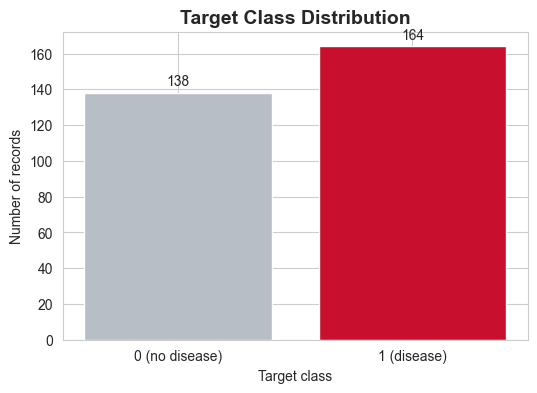

In [8]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

# Class balance
balance = df["target"].value_counts().to_frame("count")
balance["share_%"] = (df["target"].value_counts(normalize=True) * 100).round(1)
display(balance)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["0 (no disease)", "1 (disease)"], balance.sort_index()["count"], color=["#B8BEC6", "#C8102E"])
ax.bar_label(bars, padding=3)
ax.set_title("Target Class Distribution", fontsize=14, fontweight="bold"); ax.set_xlabel("Target class"); ax.set_ylabel("Number of records")
fig.savefig(f"{IMG_DIR}/01_target_distribution.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

The classes are fairly balanced (~54% / 46%), so **accuracy is meaningful**, but because this is a medical screening problem we also track **recall** (missed cases are costly) and **F1**.

### 1.2 Preprocessing decisions
| Decision | Reason |
|---|---|
| **No imputation** | There are zero missing values |
| **Drop duplicate rows** | Prevents train/test leakage (shown above) |
| **One-hot encode** `cp`, `restecg`, `slope`, `thal` | They are category codes with no natural order; leaving them as 0/1/2/3 would tell linear models and KNN that e.g. `cp=3` is "three times" `cp=1` |
| **Keep** `sex`, `exang` (binary) as 0/1 | Already numeric and correctly encoded |
| **Keep** `ca` as a number | It is a genuine count (0–4 vessels) |
| **Standard-scale** numeric features | Needed for Logistic Regression and KNN (distance/regularisation), harmless for trees |
| **Keep outliers** (e.g. `chol` = 564) | They are clinically plausible, not data errors; scaling plus tree/regularised models limit their influence |
| **Stratified 80/20 split** | Preserves the class ratio in both sets; `random_state=42` for reproducibility |
| **Fit scalers/encoders on train only** (via `Pipeline`) | Prevents test-set information leaking into preprocessing |

In [9]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("Class share in train:", y_train.mean().round(3), "| in test:", y_test.mean().round(3))

Train: 241 rows | Test: 61 rows
Class share in train: 0.544 | in test: 0.541


In [10]:
# Column groups used by the preprocessing pipeline
NUM_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
CAT_COLS = ["cp", "restecg", "slope", "thal"]
BIN_COLS = ["sex", "fbs", "exang"]

def make_preprocessor(features):
    """Scale numeric, one-hot encode categorical, pass binary through - restricted to `features`."""
    num = [c for c in NUM_COLS if c in features]
    cat = [c for c in CAT_COLS if c in features]
    binary = [c for c in BIN_COLS if c in features]
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
        ("bin", "passthrough", binary),
    ])

# Demonstrate the encoding on the training data only
demo = make_preprocessor(list(X_train.columns)).fit(X_train)
print("Features before encoding:", X_train.shape[1], "-> after encoding:", len(demo.get_feature_names_out()))
print(list(demo.get_feature_names_out()))

Features before encoding: 13 -> after encoding: 19
['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'num__ca', 'cat__cp_1', 'cat__cp_2', 'cat__cp_3', 'cat__restecg_1', 'cat__restecg_2', 'cat__slope_1', 'cat__slope_2', 'cat__thal_1', 'cat__thal_2', 'cat__thal_3', 'bin__sex', 'bin__fbs', 'bin__exang']


<a id="step-2"></a>
---
## Step 2 — Feature Engineering
All feature analysis uses the **training set only**, so the test set stays untouched.

### 2.1 Correlation analysis

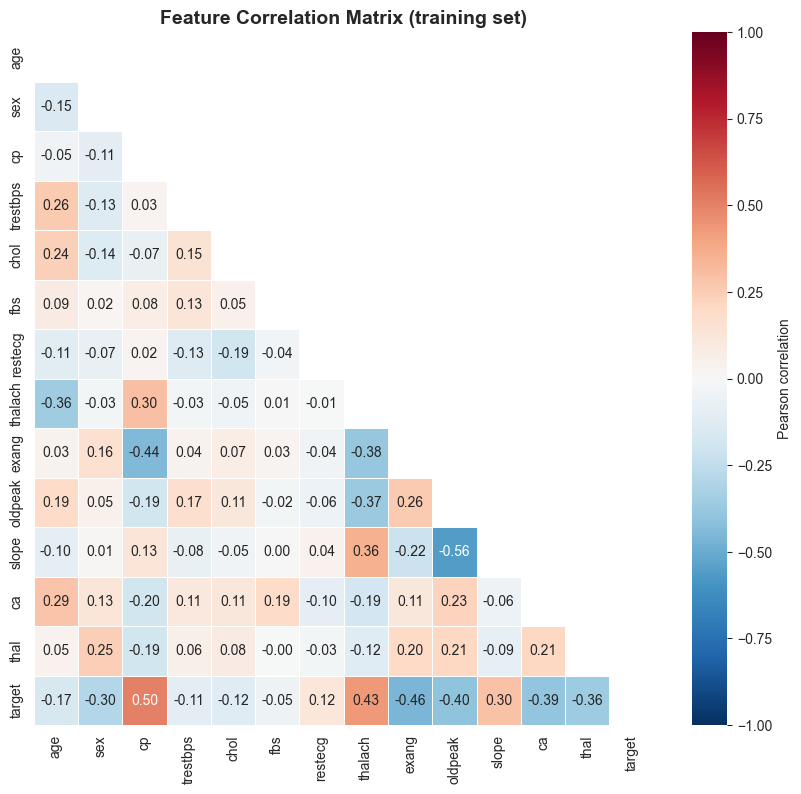

In [28]:
train_df = X_train.assign(target=y_train)
corr = train_df.corr()

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Feature Correlation Matrix (training set)", fontsize=14, fontweight="bold"); ax.grid(False)
fig.savefig(f"{IMG_DIR}/02_correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

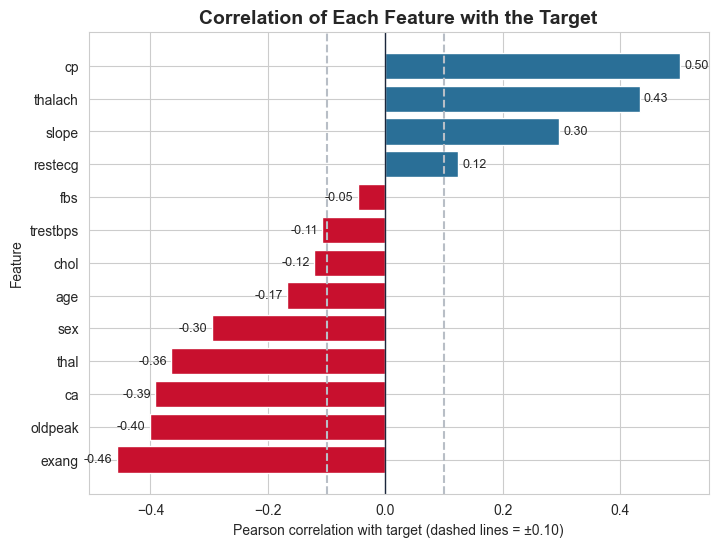

In [27]:
target_corr = corr["target"].drop("target").sort_values()
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C8102E" if v < 0 else "#2A6F97" for v in target_corr]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.axvline(0, color="#1B263B", linewidth=1)
ax.axvline(0.1, color="#B8BEC6", linestyle="--"); ax.axvline(-0.1, color="#B8BEC6", linestyle="--")
ax.set_title("Correlation of Each Feature with the Target", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson correlation with target (dashed lines = ±0.10)"); ax.set_ylabel("Feature")
fig.savefig(f"{IMG_DIR}/03_correlation_with_target.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

### 2.2 Random Forest feature importance

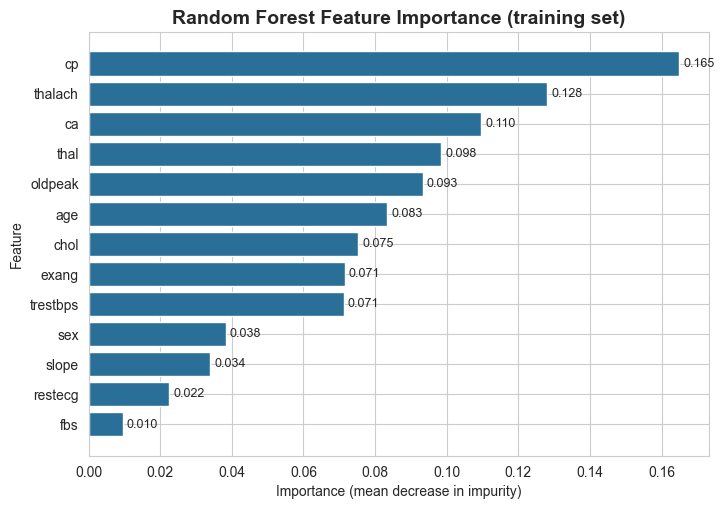

,abs_corr_with_target,rf_importance
fbs,0.047,0.010
restecg,0.124,0.022
slope,0.296,0.034
sex,0.296,0.038
trestbps,0.108,0.071
exang,0.457,0.071
chol,0.121,0.075
age,0.167,0.083
oldpeak,0.401,0.093
thal,0.365,0.098


In [13]:
rf_probe = RandomForestClassifier(n_estimators=500, random_state=42).fit(X_train, y_train)
importance = pd.Series(rf_probe.feature_importances_, index=X_train.columns).sort_values()

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(importance.index, importance.values, color="#2A6F97")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_title("Random Forest Feature Importance (training set)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance (mean decrease in impurity)"); ax.set_ylabel("Feature")
fig.savefig(f"{IMG_DIR}/04_feature_importance.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

summary = pd.DataFrame({"abs_corr_with_target": target_corr.abs(), "rf_importance": importance}).sort_values("rf_importance")
summary.round(3)

**What the two methods agree on**
- **Strongest signals:** `cp` (chest-pain type), `thalach` (max heart rate), `ca`, `oldpeak`, `exang`, `thal`.
- **Weakest signals:** `fbs` (|corr| ≈ 0.03, lowest importance) and `chol` (|corr| ≈ 0.08, weak in both methods).

Weak in both methods is a candidate for removal, but a candidate is not a decision. The next cell tests it with cross-validation.

### 2.3 Does dropping the weak features hurt? (5-fold CV on the training set)

In [29]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probe_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}
feature_sets = {
    "All 13 features": list(X_train.columns),
    "Drop fbs": [c for c in X_train.columns if c != "fbs"],
    "Drop fbs + chol": [c for c in X_train.columns if c not in ("fbs", "chol")],
    "Drop fbs + chol + restecg": [c for c in X_train.columns if c not in ("fbs", "chol", "restecg")],
}

rows = {}
for fs_name, feats in feature_sets.items():
    rows[fs_name] = {}
    for m_name, model in probe_models.items():
        pipe = Pipeline([("prep", make_preprocessor(feats)), ("model", model)])
        rows[fs_name][m_name] = cross_val_score(pipe, X_train[feats], y_train, cv=cv5, scoring="f1", n_jobs=-1).mean()

fs_table = pd.DataFrame(rows).T
fs_table["Average"] = fs_table.mean(axis=1)
fs_table.round(3)

,Logistic Regression,KNN,Random Forest,Gradient Boosting,Average
All 13 features,0.858,0.833,0.836,0.814,0.835
Drop fbs,0.858,0.844,0.837,0.823,0.840
Drop fbs + chol,0.864,0.813,0.847,0.820,0.836
Drop fbs + chol + restecg,0.864,0.827,0.818,0.816,0.831


**Decision: drop `fbs` and `chol`.**
- Both have very low correlation with the target and low RF importance.
- Removing them leaves the average cross-validated F1 essentially unchanged (0.835 to 0.836). Logistic Regression, Random Forest and Gradient Boosting improve slightly, while KNN dips (0.833 to 0.813), so the gain is small, but we get a simpler model with less noise for the same accuracy.
- `restecg` is **kept**: dropping it as well reduces the average F1, so it carries some signal.

The final feature set has **11 features** (2 irrelevant features removed).

In [15]:
DROP_COLS = ["fbs", "chol"]
FEATURES = [c for c in X_train.columns if c not in DROP_COLS]

X_train_fs, X_test_fs = X_train[FEATURES], X_test[FEATURES]
print("Final features:", FEATURES)
print(f"Train: {X_train_fs.shape} | Test: {X_test_fs.shape}")

Final features: ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Train: (241, 11) | Test: (61, 11)


<a id="step-3"></a>
---
## Step 3 — Train 4 Different Models
| Model | Why it is included |
|---|---|
| **Logistic Regression** | Interpretable linear baseline; standard in clinical risk scoring |
| **K-Nearest Neighbours** | Distance-based, non-parametric; checks whether similar patients share outcomes |
| **Random Forest** | Bagged trees; captures non-linear effects and interactions |
| **Gradient Boosting** | Boosted trees; usually the strongest tabular method when tuned |

Each model sits inside a `Pipeline` (preprocessing + model) and is tuned with **5-fold stratified `GridSearchCV` optimising F1 on the training set only**. The test set is used once, in Step 4.

In [16]:
def make_pipeline(model):
    return Pipeline([("prep", make_preprocessor(FEATURES)), ("model", model)])

search_space = {
    "Logistic Regression": (LogisticRegression(max_iter=2000),
                            {"model__C": [0.01, 0.1, 1, 10]}),
    "KNN": (KNeighborsClassifier(),
            {"model__n_neighbors": [3, 5, 7, 9, 11, 15], "model__weights": ["uniform", "distance"]}),
    "Random Forest": (RandomForestClassifier(random_state=42),
                      {"model__n_estimators": [200, 400], "model__max_depth": [3, 5, None],
                       "model__min_samples_leaf": [1, 3, 5]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
                          {"model__n_estimators": [100, 200], "model__learning_rate": [0.03, 0.1],
                           "model__max_depth": [2, 3]}),
}

tuned = {}
for name, (model, grid) in search_space.items():
    gs = GridSearchCV(make_pipeline(model), grid, cv=cv5, scoring="f1", n_jobs=-1)
    gs.fit(X_train_fs, y_train)
    tuned[name] = gs
    print(f"{name:<20} best CV F1 = {gs.best_score_:.3f}   best params = {gs.best_params_}")

Logistic Regression  best CV F1 = 0.865   best params = {'model__C': 0.1}
KNN                  best CV F1 = 0.856   best params = {'model__n_neighbors': 11, 'model__weights': 'uniform'}
Random Forest        best CV F1 = 0.847   best params = {'model__max_depth': 5, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Gradient Boosting    best CV F1 = 0.840   best params = {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}


<a id="step-4"></a>
---
## Step 4 — Evaluate & Compare All Models
Metrics (positive class = `target` 1): **Accuracy, Precision, Recall, F1, ROC-AUC**, computed on the held-out test set, next to the cross-validated F1 from training.

In [17]:
results, predictions, probabilities = [], {}, {}
for name, gs in tuned.items():
    pred = gs.predict(X_test_fs)
    proba = gs.predict_proba(X_test_fs)[:, 1]
    predictions[name], probabilities[name] = pred, proba
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "CV F1 (train)": gs.best_score_,
    })

comparison = pd.DataFrame(results).set_index("Model").sort_values("F1-Score", ascending=False)
comparison.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0).set_caption("Model Comparison (test set, n = %d)" % len(y_test))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 (train)
Model,,,,,,
Logistic Regression,0.885,0.906,0.879,0.892,0.912,0.865
Random Forest,0.836,0.848,0.848,0.848,0.898,0.847
Gradient Boosting,0.803,0.800,0.848,0.824,0.891,0.840
KNN,0.803,0.818,0.818,0.818,0.881,0.856


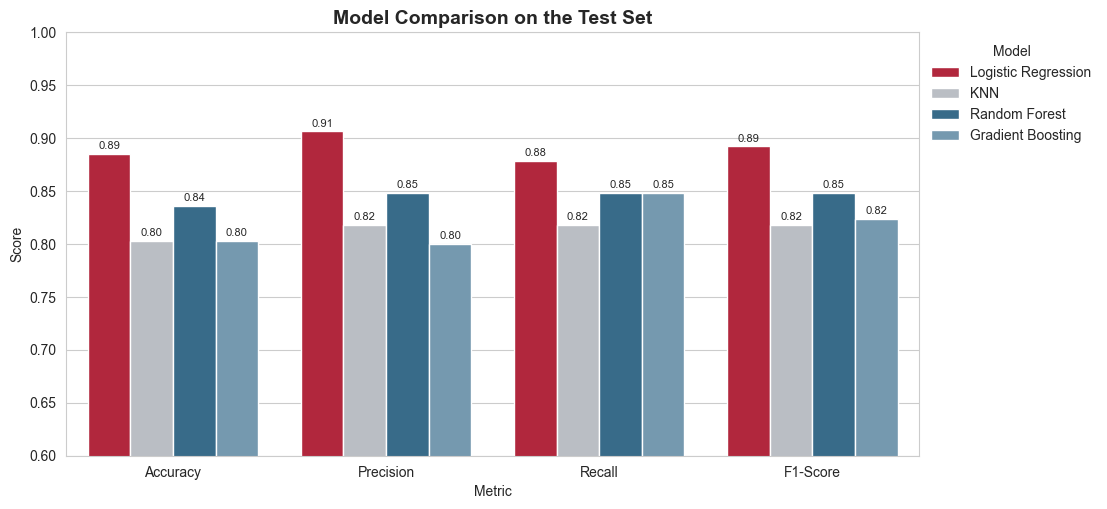

In [30]:
# Grouped bar chart of the four headline metrics
model_colors = {"Logistic Regression": "#C8102E", "KNN": "#B8BEC6", "Random Forest": "#2A6F97", "Gradient Boosting": "#6C9BB8"}
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df = comparison[metrics].reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", hue_order=list(model_colors), palette=model_colors, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
ax.set_ylim(0.6, 1.0)
ax.set_title("Model Comparison on the Test Set", fontsize=14, fontweight="bold")
ax.set_xlabel("Metric"); ax.set_ylabel("Score")
ax.legend(title="Model", bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
fig.savefig(f"{IMG_DIR}/05_model_comparison.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

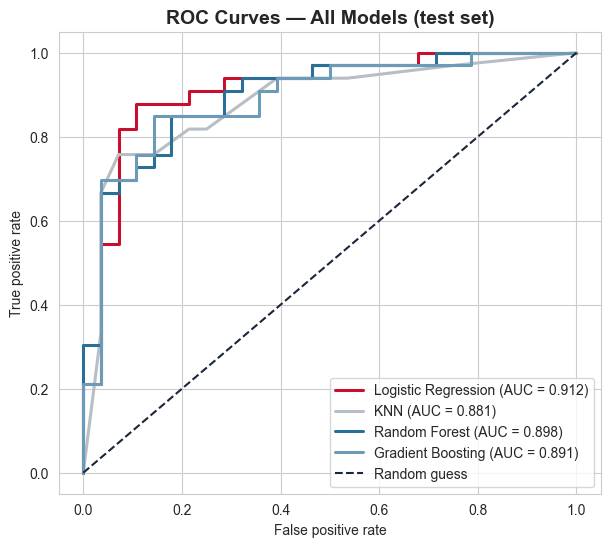

In [19]:
# ROC curves
model_colors = {"Logistic Regression": "#C8102E", "KNN": "#B8BEC6", "Random Forest": "#2A6F97", "Gradient Boosting": "#6C9BB8"}
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2.2, color=model_colors[name], label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", color="#1B263B", label="Random guess")
ax.set_title("ROC Curves — All Models (test set)", fontsize=14, fontweight="bold")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", frameon=True)
fig.savefig(f"{IMG_DIR}/06_roc_curves.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

### Robustness check — is the ranking stable?
The test set has only 61 rows, so one patient changes accuracy by ~1.6 points. To confirm the ranking is not a fluke of one split, each tuned model is re-scored with **5-fold CV repeated 3 times on the training data** (mean ± standard deviation).

In [20]:
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
rows = []
for name, gs in tuned.items():
    cvres = cross_validate(gs.best_estimator_, X_train_fs, y_train, cv=rcv,
                           scoring=["accuracy", "f1", "roc_auc"])
    rows.append({"Model": name,
                 "CV Accuracy": f"{cvres['test_accuracy'].mean():.3f} ± {cvres['test_accuracy'].std():.3f}",
                 "CV F1": f"{cvres['test_f1'].mean():.3f} ± {cvres['test_f1'].std():.3f}",
                 "CV ROC-AUC": f"{cvres['test_roc_auc'].mean():.3f} ± {cvres['test_roc_auc'].std():.3f}",
                 "_f1": cvres["test_f1"].mean()})
robust = pd.DataFrame(rows).set_index("Model").sort_values("_f1", ascending=False).drop(columns="_f1")
robust

,CV Accuracy,CV F1,CV ROC-AUC
Model,,,
Logistic Regression,0.846 ± 0.062,0.864 ± 0.057,0.905 ± 0.045
KNN,0.842 ± 0.062,0.860 ± 0.056,0.904 ± 0.044
Random Forest,0.812 ± 0.059,0.831 ± 0.053,0.900 ± 0.045
Gradient Boosting,0.809 ± 0.053,0.831 ± 0.047,0.890 ± 0.044


<a id="step-5"></a>
---
## Step 5 — Best Model Analysis & Conclusion

In [21]:
best_name = comparison.index[0]
best_model = tuned[best_name].best_estimator_
print("Best model by test F1 :", best_name)
print("Best model by CV F1   :", max(tuned, key=lambda n: tuned[n].best_score_))
print("Best hyper-parameters :", tuned[best_name].best_params_)

Best model by test F1 : Logistic Regression
Best model by CV F1   : Logistic Regression
Best hyper-parameters : {'model__C': 0.1}


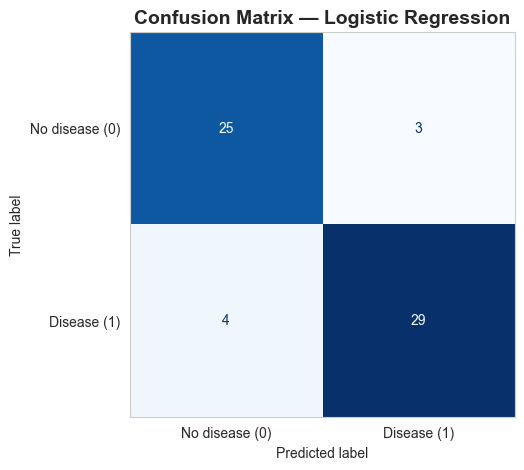

True negatives : 25   (healthy correctly cleared)
False positives: 3   (healthy flagged, extra tests)
False negatives: 4   (disease MISSED, the costly error)
True positives : 29   (disease correctly caught)


In [31]:
# Confusion matrix of the best model
cm = confusion_matrix(y_test, predictions[best_name])
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No disease (0)", "Disease (1)"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.grid(False)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
fig.savefig(f"{IMG_DIR}/07_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives : {tn}   (healthy correctly cleared)")
print(f"False positives: {fp}   (healthy flagged, extra tests)")
print(f"False negatives: {fn}   (disease MISSED, the costly error)")
print(f"True positives : {tp}   (disease correctly caught)")

In [23]:
print(classification_report(y_test, predictions[best_name], target_names=["No disease (0)", "Disease (1)"]))

                precision    recall  f1-score   support

No disease (0)       0.86      0.89      0.88        28
   Disease (1)       0.91      0.88      0.89        33

      accuracy                           0.89        61
     macro avg       0.88      0.89      0.88        61
  weighted avg       0.89      0.89      0.89        61



### Why did the best model win? Look at what it learned

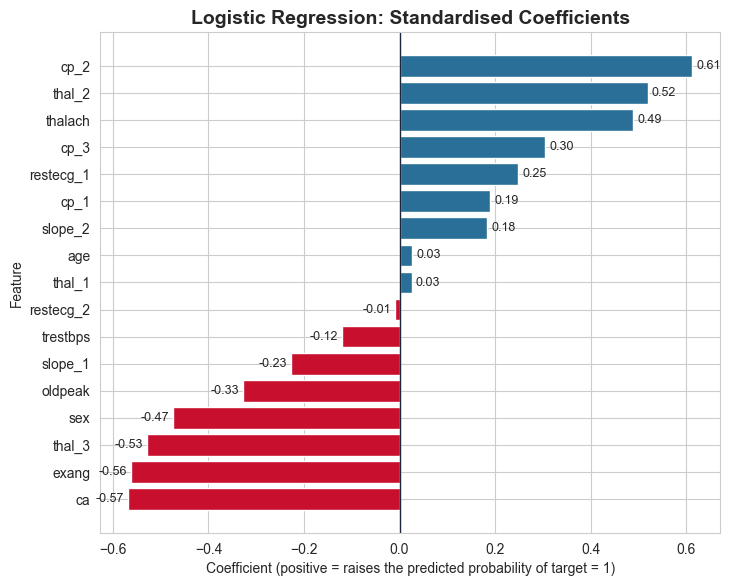

In [24]:
# Coefficients of the logistic regression -> odds ratios (only valid when the best model is linear)
prep = best_model.named_steps["prep"]
feature_names = [n.split("__")[1] for n in prep.get_feature_names_out()]
clf = best_model.named_steps["model"]

if hasattr(clf, "coef_"):
    coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values()
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6.5))
    bars = ax.barh(coefs.index, coefs.values, color=["#C8102E" if v < 0 else "#2A6F97" for v in coefs])
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.axvline(0, color="#1B263B", linewidth=1)
    ax.set_title(f"{best_name}: Standardised Coefficients", fontsize=14, fontweight="bold")
    ax.set_xlabel("Coefficient (positive = raises the predicted probability of target = 1)"); ax.set_ylabel("Feature")
    fig.savefig(f"{IMG_DIR}/08_best_model_coefficients.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()
else:
    imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values()
    imp.plot(kind="barh", figsize=(8, 6), color="#2A6F97", title=f"{best_name}: Feature Importance")

In [25]:
# Save the final model and show how it is used on a new patient
joblib.dump(best_model, f"{MODEL_DIR}/best_model.joblib")

loaded = joblib.load(f"{MODEL_DIR}/best_model.joblib")
new_patient = X_test_fs.iloc[[0]]
print("Example input:\n", new_patient.T.to_string(), sep="")
print("\nPredicted class      :", int(loaded.predict(new_patient)[0]))
print("Predicted probability:", round(float(loaded.predict_proba(new_patient)[0, 1]), 3))
print("Actual label         :", int(y_test.iloc[0]))

Example input:
             24
age        61.0
sex         0.0
cp          0.0
trestbps  145.0
restecg     0.0
thalach   146.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          0.0
thal        3.0

Predicted class      : 0
Predicted probability: 0.302
Actual label         : 0


In [26]:
# Evidence for the conclusion below
cmp_ = comparison
ev = {
    "Best model": best_name,
    "Test accuracy": f"{cmp_.loc[best_name, 'Accuracy']:.1%}",
    "Test precision / recall": f"{cmp_.loc[best_name, 'Precision']:.1%} / {cmp_.loc[best_name, 'Recall']:.1%}",
    "Test F1 / ROC-AUC": f"{cmp_.loc[best_name, 'F1-Score']:.3f} / {cmp_.loc[best_name, 'ROC-AUC']:.3f}",
    "Missed cases (FN) / false alarms (FP)": f"{fn} / {fp}",
    "Accuracy range of the other models": f"{cmp_.drop(best_name)['Accuracy'].min():.1%} to {cmp_.drop(best_name)['Accuracy'].max():.1%}",
    "Raw-data RF accuracy (leaky) vs honest": f"{leak.iloc[0, 2]:.1%} vs {leak.iloc[1, 2]:.1%}",
}
pd.Series(ev, name="Value").to_frame()

,Value
Best model,Logistic Regression
Test accuracy,88.5%
Test precision / recall,90.6% / 87.9%
Test F1 / ROC-AUC,0.892 / 0.912
Missed cases (FN) / false alarms (FP),4 / 3
Accuracy range of the other models,80.3% to 83.6%
Raw-data RF accuracy (leaky) vs honest,100.0% vs 75.4%


## 🏁 Conclusion 
1. **Best model: Logistic Regression** — it scored the highest on every test metric (accuracy 88.5%, precision 90.6%, recall 87.9%, F1 0.892, ROC-AUC 0.912) and also had the highest cross-validated F1 on the training data.
2. **Why it won:** with only 241 training records and relationships (e.g. lower peak heart rate, exercise angina and more blocked vessels all shift the risk), a linear model has the right amount of flexibility, while Random Forest, Gradient Boosting and KNN have more variance and overfit on so little data (test accuracy 80.3% to 83.6%).
3. **Clinical view:** the confusion matrix shows 29 of 33 disease cases caught and only 4 missed, with 3 false alarms; for screening, a missed case is the costly error, and a false alarm only costs a follow-up test.
4. **Data-quality finding:** 723 of 1,025 rows were duplicates; without removing them Random Forest appears 100% accurate but honest performance is about 75%.
5. **Warnings:** the test set is small (61 patients), so differences of a few points between models are within noise, and this should be treated as a screening to be validated on an external dataset.